## A Logistic function is linear regression is a type of sigmoid, a call of function with the same specific properties.Sigmoid is a mathematical fumction that takes any real number and maps to probability between 1 and 0

In [2]:
import numpy as np
import matplotlib.pyplot as plt


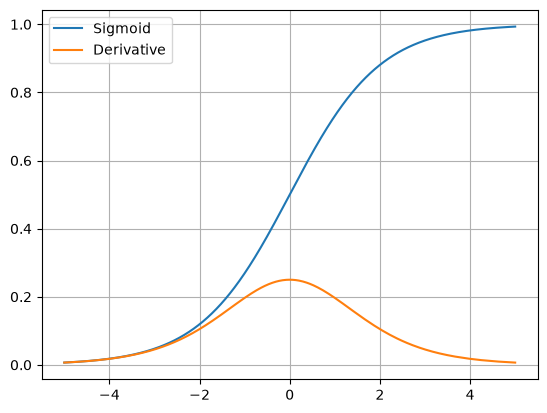

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def derivative(x, step):
    return (sigmoid(x + step) - sigmoid(x)) / step

x = np.linspace(-5, 5, 1000)

y1 = sigmoid(x)
y2 = derivative(x, 0.00000000001)

plt.plot(x, y1, label='Sigmoid')
plt.plot(x, y2, label='Derivative')

plt.legend()
plt.grid()
plt.show()

## Logistic function does not predict a class directly ( 0 or 1) it predicts the probability that a sample  belong to class 1

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [5]:
import seaborn as sns

In [6]:
df=sns.load_dataset('titanic')

In [7]:
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [8]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [9]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [10]:
print(df.shape)
print(df.info())

(891, 15)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB
None


In [11]:
#checking for null dataset
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [12]:
df.columns


Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [13]:
x=df[['pclass','sex','age','fare']]
x.head()

,pclass,sex,age,fare
0,3,male,22.0,7.2500
1,1,female,38.0,71.2833
2,3,female,26.0,7.9250
3,1,female,35.0,53.1000
4,3,male,35.0,8.0500


<Axes: xlabel='age', ylabel='Count'>

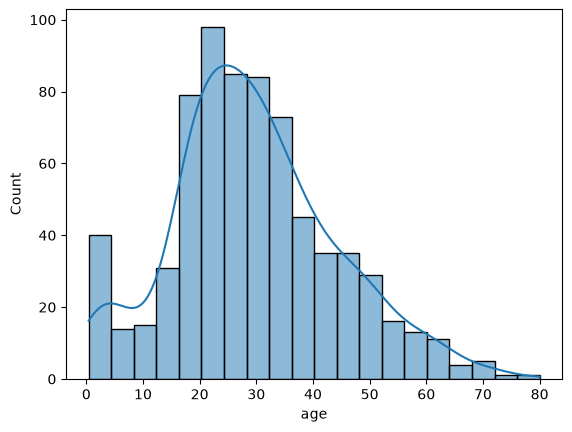

In [14]:
sns.histplot(data=df, x='age', kde=True)

In [15]:
print(df['age'].mean())
print(df['age'].median())

29.69911764705882
28.0


In [16]:
y=df['survived']

In [17]:
print(x.isnull().sum())

pclass      0
sex         0
age       177
fare        0
dtype: int64


In [18]:
x = df[['pclass', 'sex', 'age', 'fare']].copy()

In [19]:
x['age'] = x['age'].fillna(x['age'].median())

In [20]:
print(x.isnull().sum())

pclass    0
sex       0
age       0
fare      0
dtype: int64


<Figure size 1200x600 with 0 Axes>

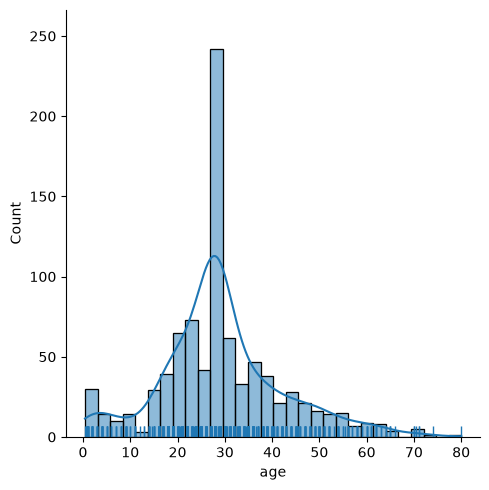

In [21]:
plt.figure(figsize=(12,6))
sns.displot(data=x, x='age', kde=True, rug=True)
plt.show()

In [22]:
x = df[['pclass', 'sex', 'age', 'fare']].copy()

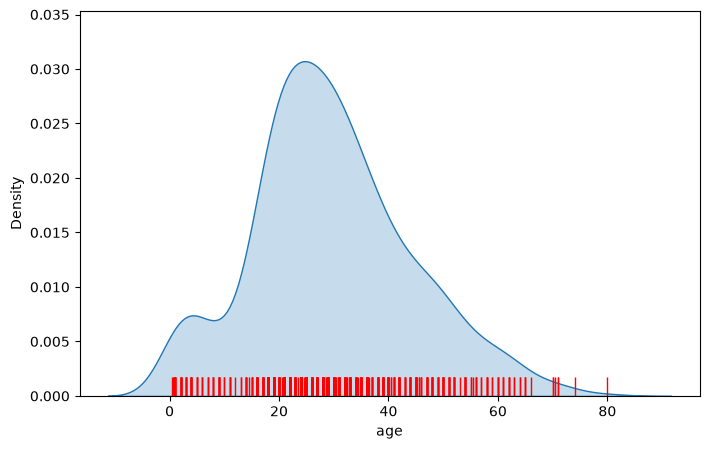

In [23]:
plt.figure(figsize=(8,5))

sns.kdeplot(data=x, x='age', fill=True)

sns.rugplot(data=x, x='age', height=0.05, color='red')

plt.show()

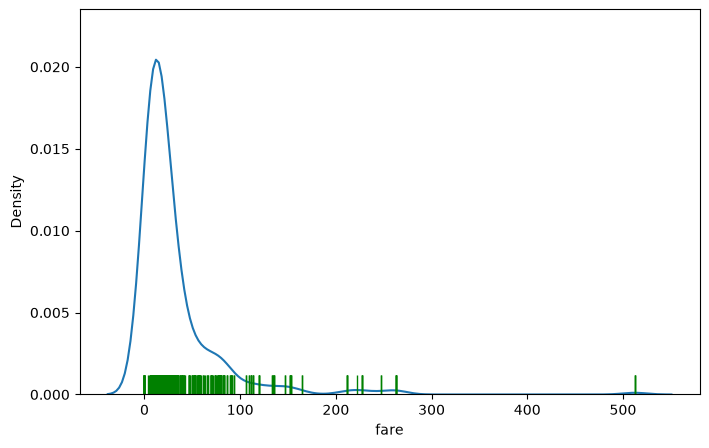

In [24]:
plt.figure(figsize=(8,5))

sns.kdeplot(data=x, x='fare')

sns.rugplot(data=x, x='fare', height=0.05, color='green')

plt.show()

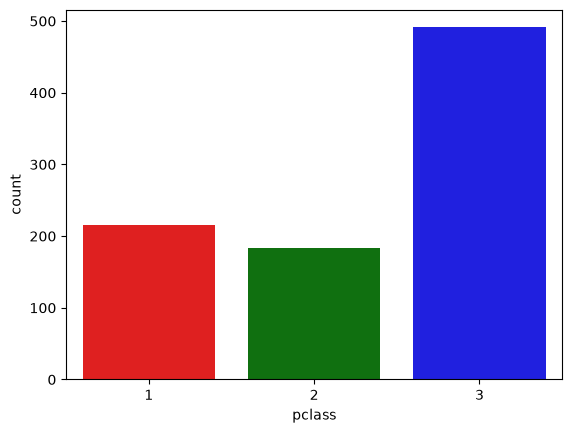

In [25]:
import warnings

warnings.filterwarnings('ignore')

sns.countplot(data=x, x='pclass', palette=['red', 'green', 'blue'])

plt.show()

In [26]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

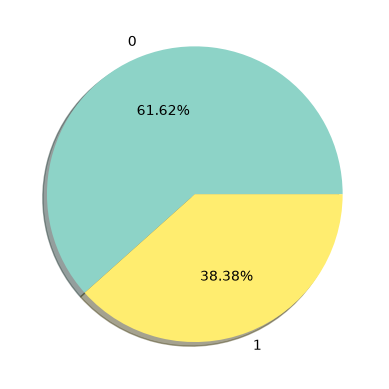

In [27]:
df['survived'].value_counts().plot(
    kind='pie',
    autopct='%1.2f%%',
    shadow=True,
    cmap='Set3'
)

plt.show()

In [28]:
print(df[(df['pclass'] == 3) & (df['survived'] == 0)].shape[0])
print(df[(df['pclass'] == 2) & (df['survived'] == 0)].shape[0])
print(df[(df['pclass'] == 1) & (df['survived'] == 0)].shape[0])

372
97
80


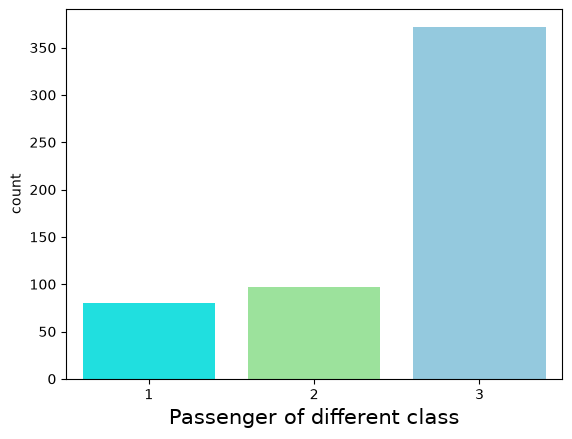

In [29]:
dead = df[df['survived'] == 0]

sns.countplot(
    data=dead,
    x='pclass',
    order=[1, 2, 3],
    palette=['aqua', 'lightgreen', 'skyblue']
)

plt.xlabel("Passenger of different class", fontsize=15)

plt.show()

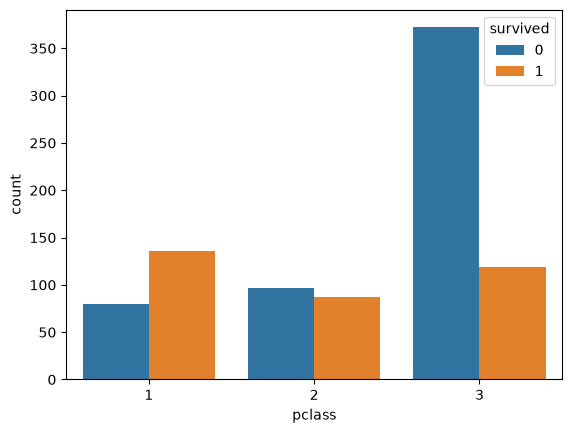

In [30]:
sns.countplot(data=df,x='pclass',hue='survived',order=[1,2,3])
plt.show()


In [31]:
x['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

<Axes: xlabel='sex'>

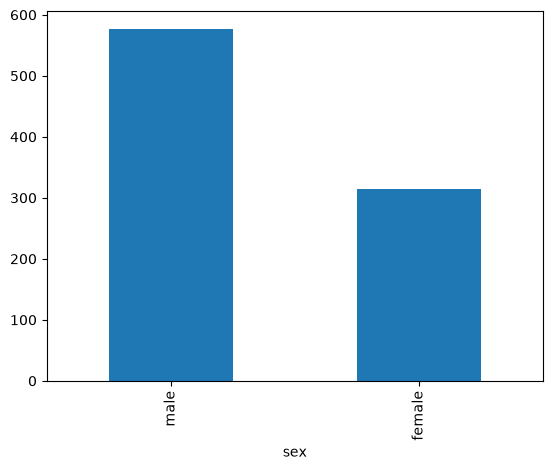

In [32]:
x['sex'].value_counts().plot(kind='bar')

In [33]:
print(df[(df['sex'] == 'male') & (df['survived'] == 0)].shape[0])

print(df[(df['sex'] == 'female') & (df['survived'] == 0)].shape[0])

468
81


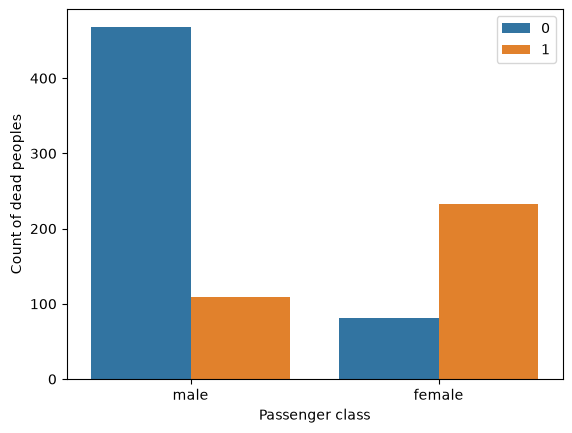

In [34]:
sns.countplot(data=df,x='sex',hue='survived',order=['male','female'])
plt.xlabel("Passenger class")
plt.ylabel("Count of dead peoples")
plt.legend(loc='upper right')
plt.show()

In [35]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pclass  891 non-null    int64  
 1   sex     891 non-null    str    
 2   age     714 non-null    float64
 3   fare    891 non-null    float64
dtypes: float64(2), int64(1), str(1)
memory usage: 32.1 KB


In [36]:
x_dummies = df[['pclass', 'sex', 'age', 'fare']]
x_dummies.head()

,pclass,sex,age,fare
0,3,male,22.0,7.2500
1,1,female,38.0,71.2833
2,3,female,26.0,7.9250
3,1,female,35.0,53.1000
4,3,male,35.0,8.0500


In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [38]:
x_dummies.head()

,pclass,sex,age,fare
0,3,male,22.0,7.2500
1,1,female,38.0,71.2833
2,3,female,26.0,7.9250
3,1,female,35.0,53.1000
4,3,male,35.0,8.0500


In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

x_dummies = df[['pclass', 'sex', 'age', 'fare']].copy()

x_dummies['sex'] = le.fit_transform(x_dummies['sex'])

In [40]:
x_dummies['age'] = x_dummies['age'].fillna(x_dummies['age'].median())

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x_dummies,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [43]:
x_dummies = df[['pclass', 'sex', 'age', 'fare']].copy()

In [44]:
le = LabelEncoder()

x_dummies['sex'] = le.fit_transform(x_dummies['sex'])

In [45]:
log_reg = LogisticRegression()

In [46]:
y = df['survived']

In [47]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_dummies,
    y,
    test_size=0.2,
    random_state=42
)

In [48]:
x_dummies = df[['pclass', 'sex', 'age', 'fare']].copy()

# Encode sex
le = LabelEncoder()
x_dummies['sex'] = le.fit_transform(x_dummies['sex'])

# Fill missing age values
x_dummies['age'] = x_dummies['age'].fillna(x_dummies['age'].median())

# Check missing values
print(x_dummies.isnull().sum())

pclass    0
sex       0
age       0
fare      0
dtype: int64


In [49]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [50]:
x_dummies = df[['pclass', 'sex', 'age', 'fare']].copy()

x_dummies['sex'] = le.fit_transform(x_dummies['sex'])

x_dummies['age'] = x_dummies['age'].fillna(x_dummies['age'].median())

y = df['survived']

In [51]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_dummies,
    y,
    test_size=0.2,
    random_state=42
)

In [52]:
sc = StandardScaler()

x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [53]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()

log_reg.fit(x_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [54]:
y_pred = log_reg.predict(x_test_scaled)

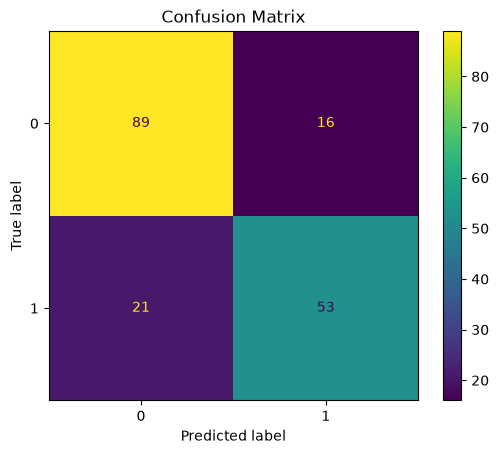

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Confusion Matrix")
plt.show()

In [56]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83       105
           1       0.77      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



## probability prediction

In [57]:
y_pred=log_reg.predict(X_test_scaled)

In [58]:
y_prob = log_reg.predict_proba(x_test_scaled)[:, 1]

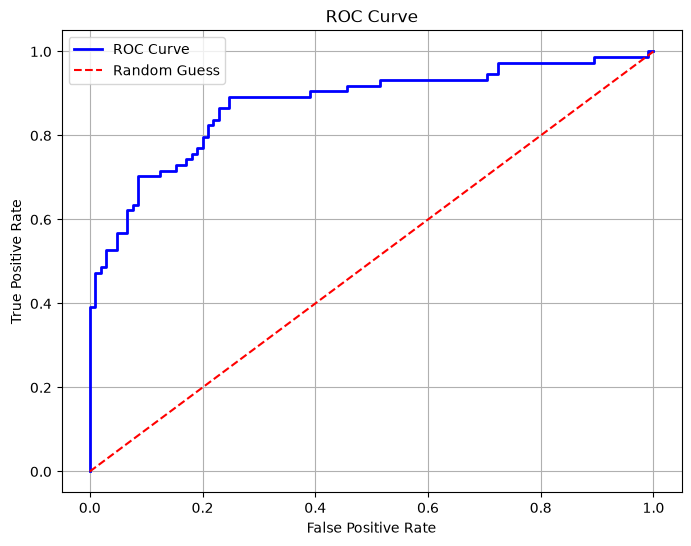

In [62]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label='ROC Curve')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

AUC Score: 0.8745173745173744


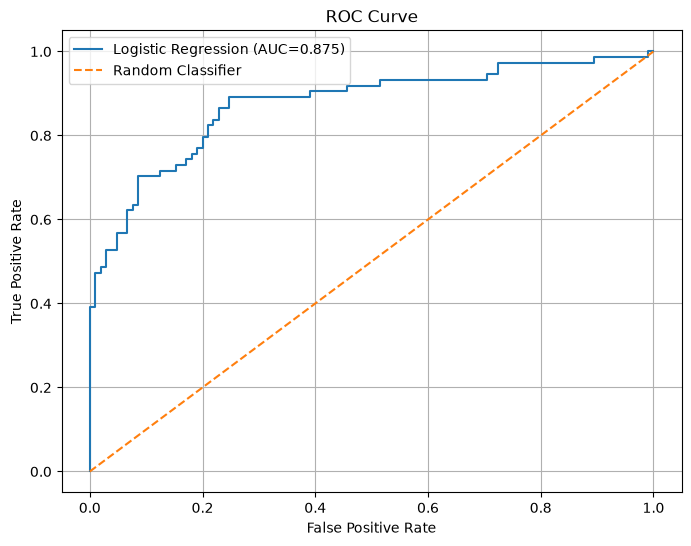

In [63]:

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC={auc_score:.3f})")

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle='--', label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()